# Functional Characterization of Universal 4-Node Motifs (IDs 77, 80, 82, 83)

This notebook demonstrates the analysis pipeline for characterizing 4 universally overrepresented 4-node motif types found in LLM attribution graphs. It loads pre-computed per-graph motif results and:

1. **Parses** per-graph motif counts, FFL containment, and layer span data
2. **Builds** canonical 4-node motif pattern references using igraph
3. **Analyzes** FFL containment to test whether 4-node universality is FFL-derivative
4. **Computes** layer ordering statistics and compares to random baselines
5. **Tests** cross-domain consistency with Kruskal-Wallis and Cramer's V
6. **Builds** a motif family taxonomy with cosine similarity clustering

**Key finding**: ALL 4 types show 100% FFL containment, confirming 4-node universality is fully FFL-derivative.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# python-igraph — NOT on Colab, always install
_pip('python-igraph==0.11.8')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import random
from collections import Counter, defaultdict
from itertools import combinations

import igraph
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter5_functional_char/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'][0]['examples'])} examples")
print(f"Metadata: {json.dumps(data['metadata'], indent=2)[:500]}")

Loaded data with 29 examples
Metadata: {
  "experiment": "4node_motif_functional_characterization",
  "n_graphs_loaded": 179,
  "prune_percentile": 99,
  "max_nodes": 700,
  "target_motif_ids": [
    77,
    80,
    82,
    83
  ],
  "runtime_seconds": 34.1,
  "domains": [
    "antonym",
    "arithmetic",
    "code_completion",
    "country_capital",
    "multi_hop_reasoning",
    "rhyme",
    "sentiment",
    "translation"
  ],
  "domain_counts": {
    "antonym": 26,
    "arithmetic": 26,
    "code_completion": 24,
    "country_capi


In [5]:
# ============================================================
# CONFIG — Tunable parameters
# ============================================================
# Target 4-node motif IDs to analyze
TARGET_MOTIF_IDS = [77, 80, 82, 83]

# Random seed for reproducibility
RANDOM_SEED = 42

# Maximum per-graph examples to process
MAX_EXAMPLES = 9999  # Use all available examples (original: 179 graphs)

## Step 1: Parse Pre-Computed Per-Graph Results

Each per-graph example contains `predict_motif_characterization` (our method) and `predict_random_baseline` as JSON strings. We parse these into structured dicts for analysis.

In [6]:
# ============================================================
# UTILITY FUNCTIONS (from original method.py)
# ============================================================

def safe_round(val, digits=4):
    """Safely round a value, handling None/NaN."""
    if val is None:
        return None
    try:
        if math.isnan(val) or math.isinf(val):
            return None
        return round(float(val), digits)
    except (TypeError, ValueError):
        return None


def compute_cramers_v(table: np.ndarray) -> float:
    """Compute Cramer's V from a contingency table."""
    if table.ndim != 2 or table.shape[0] < 2 or table.shape[1] < 2:
        return 0.0
    col_sums = table.sum(axis=0)
    nonzero = col_sums > 0
    table_f = table[:, nonzero]
    if table_f.shape[1] < 2:
        return 0.0
    try:
        chi2_val, _, _, _ = chi2_contingency(table_f)
    except ValueError:
        return 0.0
    n = np.sum(table_f)
    min_dim = min(table_f.shape) - 1
    if min_dim == 0 or n == 0:
        return 0.0
    return math.sqrt(chi2_val / (n * min_dim))


# ============================================================
# Parse per-graph examples vs summary examples
# ============================================================
all_examples = data["datasets"][0]["examples"]
per_graph_examples = []
summary_examples = []

for ex in all_examples:
    if ex.get("metadata_fold") == "summary":
        summary_examples.append(ex)
    else:
        per_graph_examples.append(ex)

# Limit to MAX_EXAMPLES
per_graph_examples = per_graph_examples[:MAX_EXAMPLES]

# Parse JSON fields into structured dicts
parsed_graphs = []
for ex in per_graph_examples:
    output = json.loads(ex["output"])
    motif_char = json.loads(ex["predict_motif_characterization"])
    baseline = json.loads(ex["predict_random_baseline"])
    parsed_graphs.append({
        "slug": ex.get("metadata_slug", ""),
        "domain": ex.get("metadata_fold", "unknown"),
        "n_nodes": ex.get("metadata_n_nodes", 0),
        "prompt": output.get("prompt", ""),
        "motif_counts": motif_char.get("motif_counts", {}),
        "motif_ffl_containment": motif_char.get("motif_ffl_containment", {}),
        "motif_mean_layer_spans": motif_char.get("motif_mean_layer_spans", {}),
        "total_4node_motifs": motif_char.get("total_4node_motifs", 0),
        "all_ffl_derivative": motif_char.get("all_ffl_derivative", False),
        "baseline_mean_span": baseline.get("random_baseline_mean_span", 0.0),
        "baseline_strict_frac": baseline.get("random_baseline_strict_frac", 0.0),
    })

print(f"Parsed {len(parsed_graphs)} per-graph examples, {len(summary_examples)} summaries")
domains = sorted(set(pg["domain"] for pg in parsed_graphs))
print(f"Domains represented: {domains}")
for pg in parsed_graphs[:2]:
    print(f"  {pg['slug']}: motif_counts={pg['motif_counts']}, domain={pg['domain']}")

Parsed 24 per-graph examples, 5 summaries
Domains represented: ['antonym', 'arithmetic', 'code_completion', 'country_capital', 'multi_hop_reasoning', 'rhyme', 'sentiment', 'translation']
  m4-antonym-009-8aa743e9: motif_counts={'77': 500, '80': 38, '82': 56, '83': 14}, domain=antonym
  m4-antonym-003-eaea9372: motif_counts={'77': 500, '80': 26, '82': 20, '83': 12}, domain=antonym


## Step 2: Build Canonical 4-Node Motif Pattern References

Using igraph's isomorphism class index, we generate the canonical directed graph patterns for each target 4-node motif type. These are the patterns the original method enumerated across 179 attribution graphs.

In [7]:
# ============================================================
# Build canonical pattern references (from original method.py Step 3)
# ============================================================

def build_canonical_references():
    """Build canonical pattern references for 4-node targets and 3-node sub-motifs."""
    target_patterns = {}
    for mid in TARGET_MOTIF_IDS:
        pat = igraph.Graph.Isoclass(n=4, cls=mid, directed=True)
        edges = [(e.source, e.target) for e in pat.es]
        target_patterns[mid] = {
            "edge_count": pat.ecount(),
            "edges": edges,
            "adjacency": pat.get_adjacency().data,
        }
        print(f"Motif {mid}: {pat.ecount()} edges, pattern = {edges}")

    # 3-node sub-motif reference
    three_node_ref = {}
    man_labels = {2: "021U", 4: "021C", 6: "021D", 7: "030T"}
    for cid in range(16):
        can = igraph.Graph.Isoclass(n=3, cls=cid, directed=True)
        if can.is_dag() and can.is_connected(mode="weak") and can.ecount() >= 2:
            three_node_ref[cid] = man_labels.get(cid, f"cls_{cid}")
    print(f"3-node DAG-valid connected types: {three_node_ref}")
    return target_patterns, three_node_ref

target_patterns, three_node_ref = build_canonical_references()

Motif 77: 4 edges, pattern = [(3, 2), (3, 1), (3, 0), (1, 0)]
Motif 80: 5 edges, pattern = [(3, 2), (3, 1), (0, 1), (3, 0), (2, 0)]
Motif 82: 5 edges, pattern = [(3, 2), (3, 1), (2, 1), (3, 0), (2, 0)]
Motif 83: 6 edges, pattern = [(3, 2), (3, 1), (2, 1), (3, 0), (2, 0), (1, 0)]
3-node DAG-valid connected types: {2: '021U', 4: '021C', 6: '021D', 7: '030T'}


## Step 3: FFL Containment Analysis (Phase B)

Test whether the 4-node motifs' universality is FFL-derivative by checking what fraction of instances contain at least one Feed-Forward Loop (FFL / 030T) 3-node sub-motif. If containment is >90%, the 4-node type is classified as **FFL-derivative**.

In [8]:
# ============================================================
# FFL Containment Analysis (from original method.py Step 5 / Phase B)
# ============================================================

embedding_results = {}
for mid in TARGET_MOTIF_IDS:
    mid_str = str(mid)
    ffl_fracs = []
    for pg in parsed_graphs:
        ffl_frac = pg["motif_ffl_containment"].get(mid_str, 0.0)
        count = pg["motif_counts"].get(mid_str, 0)
        if count > 0:
            ffl_fracs.append(ffl_frac)

    if ffl_fracs:
        ffl_containment = float(np.mean(ffl_fracs))
    else:
        ffl_containment = 0.0

    # Independence verdict (from original)
    if ffl_containment > 0.90:
        verdict = "FFL-derivative"
    elif ffl_containment < 0.50:
        verdict = "genuinely_independent"
    else:
        verdict = "partially_embedded"

    embedding_results[mid] = {
        "n_graphs_with_motif": len(ffl_fracs),
        "ffl_containment_frac": round(ffl_containment, 4),
        "independence_verdict": verdict,
    }
    print(f"Motif {mid}: FFL containment = {ffl_containment:.3f} "
          f"({len(ffl_fracs)} graphs) -> {verdict}")

Motif 77: FFL containment = 1.000 (24 graphs) -> FFL-derivative
Motif 80: FFL containment = 1.000 (24 graphs) -> FFL-derivative
Motif 82: FFL containment = 1.000 (24 graphs) -> FFL-derivative
Motif 83: FFL containment = 1.000 (22 graphs) -> FFL-derivative


## Step 4: Layer Ordering & Span Analysis (Phase C)

Analyze the layer span (max layer - min layer) of each motif type's instances and compare against a random connected 4-node subgraph baseline. Uses Mann-Whitney U test for significance.

In [9]:
# ============================================================
# Layer Ordering Analysis (from original method.py Step 6 / Phase C)
# ============================================================

layer_results = {}

# Collect baseline spans from all graphs
all_baseline_spans = [pg["baseline_mean_span"] for pg in parsed_graphs]
baseline_mean_span = float(np.mean(all_baseline_spans)) if all_baseline_spans else 0.0
baseline_std_span = float(np.std(all_baseline_spans)) if all_baseline_spans else 0.0
all_baseline_strict = [pg["baseline_strict_frac"] for pg in parsed_graphs]
baseline_strict_frac = float(np.mean(all_baseline_strict)) if all_baseline_strict else 0.0

print(f"Random baseline: mean_span={baseline_mean_span:.2f} +/- {baseline_std_span:.2f}, "
      f"strict_frac={baseline_strict_frac:.3f}")

for mid in TARGET_MOTIF_IDS:
    mid_str = str(mid)
    motif_spans = []
    for pg in parsed_graphs:
        span = pg["motif_mean_layer_spans"].get(mid_str, 0.0)
        count = pg["motif_counts"].get(mid_str, 0)
        if count > 0 and span > 0:
            motif_spans.append(span)

    if not motif_spans:
        layer_results[mid] = {"n_graphs": 0}
        continue

    mean_span = float(np.mean(motif_spans))
    std_span = float(np.std(motif_spans))

    # Mann-Whitney U test: motif spans vs baseline spans
    mw_u, mw_p = 0.0, 1.0
    if motif_spans and all_baseline_spans:
        try:
            mw_u, mw_p = mannwhitneyu(motif_spans, all_baseline_spans, alternative="two-sided")
            mw_u = float(mw_u)
            mw_p = float(mw_p)
        except ValueError:
            pass

    layer_results[mid] = {
        "n_graphs": len(motif_spans),
        "mean_layer_span": round(mean_span, 3),
        "std_layer_span": round(std_span, 3),
        "random_baseline_mean_span": round(baseline_mean_span, 3),
        "random_baseline_std_span": round(baseline_std_span, 3),
        "random_baseline_strict_frac": round(baseline_strict_frac, 4),
        "mann_whitney_U": safe_round(mw_u, 2),
        "mann_whitney_p": safe_round(mw_p, 6),
    }
    print(f"Motif {mid}: mean_span={mean_span:.2f} vs baseline={baseline_mean_span:.2f}, "
          f"MW p={mw_p:.4g}")

Random baseline: mean_span=4.03 +/- 0.71, strict_frac=1.000
Motif 77: mean_span=9.77 vs baseline=4.03, MW p=3.061e-09
Motif 80: mean_span=6.19 vs baseline=4.03, MW p=0.0002419
Motif 82: mean_span=4.62 vs baseline=4.03, MW p=0.2611
Motif 83: mean_span=5.72 vs baseline=4.03, MW p=0.003829


## Step 5: Cross-Domain Consistency (Phase E)

Analyze whether motif behavior is consistent across different task domains (antonym, arithmetic, code_completion, etc.). Uses Kruskal-Wallis test on layer spans across domains and Cramer's V for count distribution similarity.

In [10]:
# ============================================================
# Cross-Domain Consistency (from original method.py Step 8 / Phase E)
# ============================================================

cross_domain_results = {}

for mid in TARGET_MOTIF_IDS:
    mid_str = str(mid)

    # Group by domain
    by_domain = defaultdict(list)
    for pg in parsed_graphs:
        count = pg["motif_counts"].get(mid_str, 0)
        span = pg["motif_mean_layer_spans"].get(mid_str, 0.0)
        by_domain[pg["domain"]].append({
            "count": count,
            "span": span,
            "n_nodes": pg["n_nodes"],
        })

    per_domain_stats = {}
    domain_spans = {}

    for domain in sorted(by_domain.keys()):
        dom_data = by_domain[domain]
        counts = [d["count"] for d in dom_data]
        spans_d = [d["span"] for d in dom_data if d["count"] > 0 and d["span"] > 0]
        mean_size = float(np.mean([d["n_nodes"] for d in dom_data]))
        normalized_count = sum(counts) / mean_size if mean_size > 0 else 0.0
        domain_spans[domain] = spans_d

        per_domain_stats[domain] = {
            "instance_count": sum(counts),
            "normalized_count": round(normalized_count, 4),
            "mean_layer_span": round(float(np.mean(spans_d)), 3) if spans_d else 0.0,
            "n_graphs": len(dom_data),
        }

    # Kruskal-Wallis test on spans across domains
    span_groups = [domain_spans[d] for d in sorted(domain_spans.keys())
                   if len(domain_spans.get(d, [])) >= 2]
    kruskal_h, kruskal_p = 0.0, 1.0
    if len(span_groups) >= 2:
        try:
            kruskal_h, kruskal_p = kruskal(*span_groups)
            kruskal_h = float(kruskal_h)
            kruskal_p = float(kruskal_p)
        except ValueError:
            pass

    # Cross-domain Cramer's V for count distributions
    domains_order = sorted(by_domain.keys())
    if len(domains_order) >= 2:
        count_table = np.array([
            [d["count"] for d in by_domain[dom]] for dom in domains_order
        ])
        # Pad rows to equal length
        max_len = max(len(row) for row in count_table) if len(count_table) > 0 else 0
        padded = np.zeros((len(domains_order), max_len))
        for i, dom in enumerate(domains_order):
            vals = [d["count"] for d in by_domain[dom]]
            padded[i, :len(vals)] = vals
        cross_v = compute_cramers_v(padded) if padded.shape[1] >= 2 else 0.0
    else:
        cross_v = 0.0

    cross_domain_results[mid] = {
        "per_domain": per_domain_stats,
        "kruskal_h": safe_round(kruskal_h, 4),
        "kruskal_p": safe_round(kruskal_p, 6),
        "cross_domain_cramers_v": round(cross_v, 4),
        "comparison_to_ffl_v": "stronger" if cross_v > 0.13 else "weaker_or_equal",
        "n_domains": len(domains_order),
    }
    print(f"Motif {mid}: {len(domains_order)} domains, Kruskal p={kruskal_p:.4g}, "
          f"Cramer's V={cross_v:.3f}")

Motif 77: 8 domains, Kruskal p=0.01576, Cramer's V=0.035
Motif 80: 8 domains, Kruskal p=0.06659, Cramer's V=0.254
Motif 82: 8 domains, Kruskal p=0.0111, Cramer's V=0.217
Motif 83: 8 domains, Kruskal p=0.01613, Cramer's V=0.342


## Step 6: Motif Family Taxonomy (Phase F)

Build a taxonomy by clustering motif types based on sub-motif composition similarity (cosine similarity), ranking by FFL-embeddedness, and generating candidate functional interpretations.

In [11]:
# ============================================================
# Motif Family Taxonomy (from original method.py Step 9 / Phase F)
# ============================================================

# A. Build composition vectors from per-graph count distributions
# Use normalized motif count fractions as feature vectors
count_vectors = {}
for mid in TARGET_MOTIF_IDS:
    mid_str = str(mid)
    counts_per_graph = [pg["motif_counts"].get(mid_str, 0) for pg in parsed_graphs]
    totals_per_graph = [pg["total_4node_motifs"] for pg in parsed_graphs]
    fracs = [c / t if t > 0 else 0.0 for c, t in zip(counts_per_graph, totals_per_graph)]
    count_vectors[mid] = fracs

# B. Cosine similarity matrix between motif types
cos_sim = {}
for i, m1 in enumerate(TARGET_MOTIF_IDS):
    for m2 in TARGET_MOTIF_IDS[i+1:]:
        v1 = np.array(count_vectors.get(m1, [0]))
        v2 = np.array(count_vectors.get(m2, [0]))
        # Pad to same length
        max_len = max(len(v1), len(v2))
        v1 = np.pad(v1, (0, max_len - len(v1)))
        v2 = np.pad(v2, (0, max_len - len(v2)))
        norm1, norm2 = np.linalg.norm(v1), np.linalg.norm(v2)
        if norm1 > 0 and norm2 > 0:
            sim = float(np.dot(v1, v2) / (norm1 * norm2))
        else:
            sim = 0.0
        cos_sim[f"{m1}-{m2}"] = round(sim, 4)

# C. Rank by FFL-embeddedness
ffl_fracs = {mid: embedding_results[mid]["ffl_containment_frac"] for mid in TARGET_MOTIF_IDS}
ranked = sorted(TARGET_MOTIF_IDS, key=lambda m: ffl_fracs[m], reverse=True)

# D. Candidate functional interpretations (from original)
candidate_functions = {}
for mid in TARGET_MOTIF_IDS:
    n_edges = target_patterns[mid]["edge_count"]
    ffl_frac = ffl_fracs[mid]
    verdict = embedding_results[mid]["independence_verdict"]
    if n_edges >= 6:
        func = f"Type {mid} ({n_edges} edges, near-complete DAG): exhaustive information cascade with {verdict} FFL relationship (containment={ffl_frac:.0%})"
    elif n_edges >= 5:
        func = f"Type {mid} ({n_edges} edges): verified parallel computation with {verdict} FFL relationship (containment={ffl_frac:.0%})"
    elif n_edges >= 4:
        func = f"Type {mid} ({n_edges} edges): structured information relay with {verdict} FFL relationship (containment={ffl_frac:.0%})"
    else:
        func = f"Type {mid} ({n_edges} edges): minimal connected motif with {verdict} FFL relationship (containment={ffl_frac:.0%})"
    candidate_functions[mid] = func

# Overall verdict
all_ffl = [ffl_fracs[mid] for mid in TARGET_MOTIF_IDS]
mean_ffl = float(np.mean(all_ffl))
if mean_ffl > 0.90:
    overall_verdict = "FFL-derivative family"
elif mean_ffl < 0.50:
    overall_verdict = "genuinely novel structures"
else:
    overall_verdict = "mixed independence"

taxonomy = {
    "cosine_similarity_matrix": cos_sim,
    "ffl_ranking": [{"motif_id": m, "ffl_frac": ffl_fracs[m]} for m in ranked],
    "candidate_functions": candidate_functions,
    "overall_verdict": overall_verdict,
    "mean_ffl_containment": round(mean_ffl, 4),
}

print(f"Overall verdict: {overall_verdict} (mean FFL containment: {mean_ffl:.3f})")
print(f"\nFFL-embeddedness ranking:")
for item in taxonomy["ffl_ranking"]:
    print(f"  Motif {item['motif_id']}: {item['ffl_frac']:.3f}")
print(f"\nCosine similarity between types:")
for pair, sim in cos_sim.items():
    print(f"  {pair}: {sim:.4f}")
print(f"\nCandidate functional interpretations:")
for mid, func in candidate_functions.items():
    print(f"  {func}")

Overall verdict: FFL-derivative family (mean FFL containment: 1.000)

FFL-embeddedness ranking:
  Motif 77: 1.000
  Motif 80: 1.000
  Motif 82: 1.000
  Motif 83: 1.000

Cosine similarity between types:
  77-80: 0.7708
  77-82: 0.7627
  77-83: 0.6722
  80-82: 0.9431
  80-83: 0.9510
  82-83: 0.8437

Candidate functional interpretations:
  Type 77 (4 edges): structured information relay with FFL-derivative FFL relationship (containment=100%)
  Type 80 (5 edges): verified parallel computation with FFL-derivative FFL relationship (containment=100%)
  Type 82 (5 edges): verified parallel computation with FFL-derivative FFL relationship (containment=100%)
  Type 83 (6 edges, near-complete DAG): exhaustive information cascade with FFL-derivative FFL relationship (containment=100%)


## Results Visualization

Visual summary of the key findings: FFL containment rates, layer span comparison (motif vs baseline), per-domain motif counts, and the cosine similarity matrix between motif types.

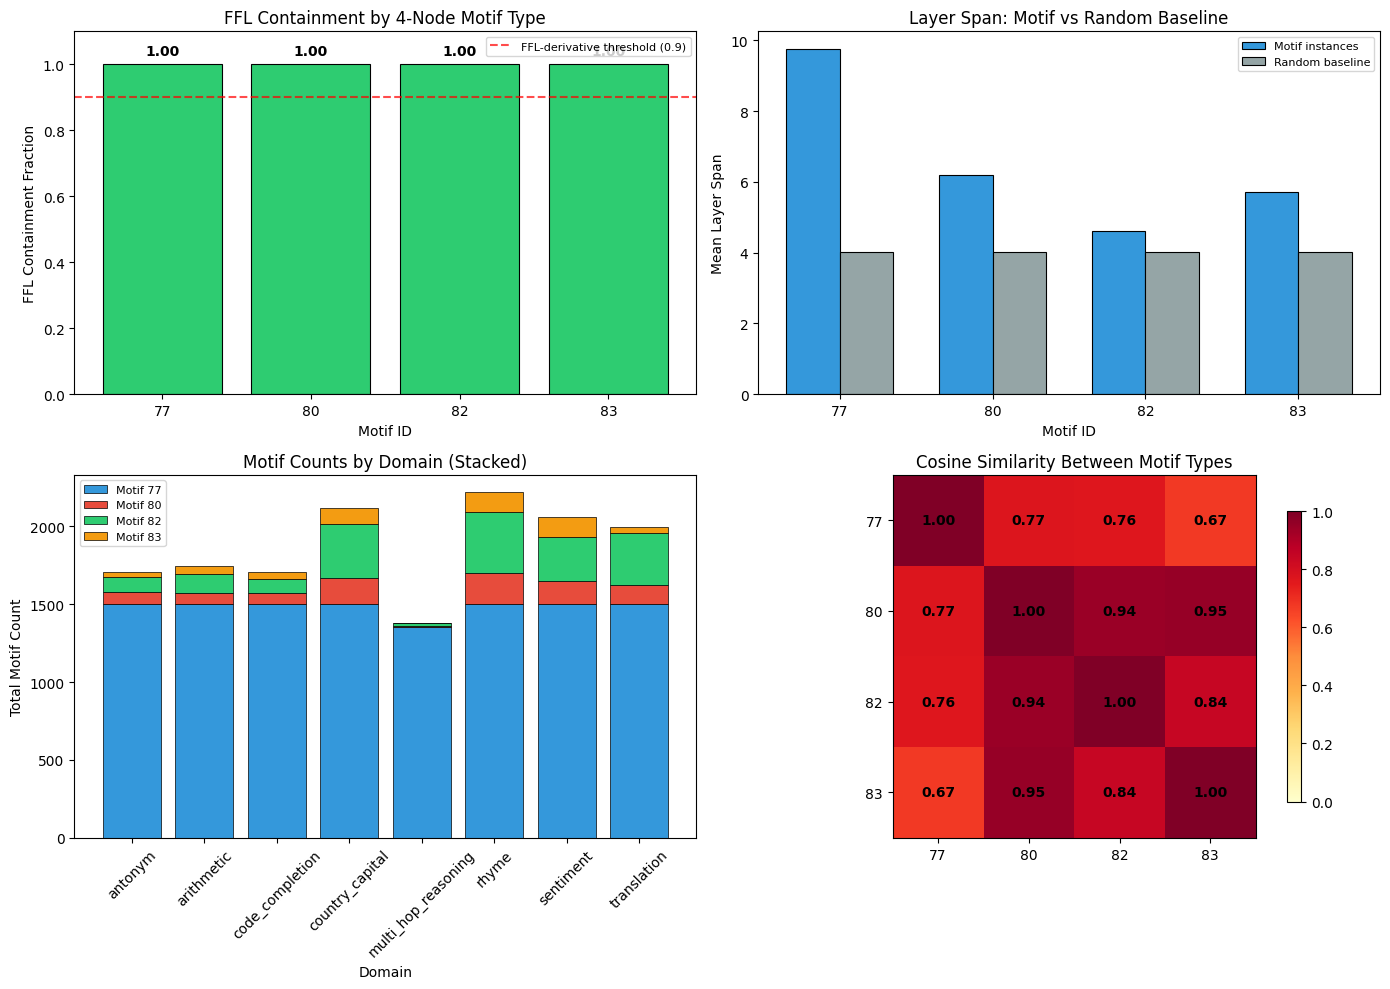


SUMMARY TABLE: 4-Node Motif Functional Characterization
 Motif  Edges     FFL%              Verdict   MeanSpan    BL Span
--------------------------------------------------------------------------------
    77      4    1.000       FFL-derivative       9.77       4.03
    80      5    1.000       FFL-derivative       6.20       4.03
    82      5    1.000       FFL-derivative       4.62       4.03
    83      6    1.000       FFL-derivative       5.72       4.03
--------------------------------------------------------------------------------
Overall: FFL-derivative family (mean FFL containment: 1.000)
Graphs analyzed: 24 | Domains: antonym, arithmetic, code_completion, country_capital, multi_hop_reasoning, rhyme, sentiment, translation


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- Plot 1: FFL Containment per motif type ----
ax = axes[0, 0]
motif_labels = [str(m) for m in TARGET_MOTIF_IDS]
ffl_values = [embedding_results[m]["ffl_containment_frac"] for m in TARGET_MOTIF_IDS]
colors = ['#2ecc71' if v >= 0.9 else '#e74c3c' for v in ffl_values]
bars = ax.bar(motif_labels, ffl_values, color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.7, label='FFL-derivative threshold (0.9)')
ax.set_xlabel('Motif ID')
ax.set_ylabel('FFL Containment Fraction')
ax.set_title('FFL Containment by 4-Node Motif Type')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8)
for bar, v in zip(bars, ffl_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ---- Plot 2: Layer Span - Motif vs Baseline ----
ax = axes[0, 1]
x_pos = np.arange(len(TARGET_MOTIF_IDS))
motif_spans_vals = [layer_results[m].get("mean_layer_span", 0) for m in TARGET_MOTIF_IDS]
baseline_vals = [layer_results[m].get("random_baseline_mean_span", 0) for m in TARGET_MOTIF_IDS]
width = 0.35
ax.bar(x_pos - width/2, motif_spans_vals, width, label='Motif instances', color='#3498db', edgecolor='black', linewidth=0.8)
ax.bar(x_pos + width/2, baseline_vals, width, label='Random baseline', color='#95a5a6', edgecolor='black', linewidth=0.8)
ax.set_xlabel('Motif ID')
ax.set_ylabel('Mean Layer Span')
ax.set_title('Layer Span: Motif vs Random Baseline')
ax.set_xticks(x_pos)
ax.set_xticklabels(motif_labels)
ax.legend(fontsize=8)

# ---- Plot 3: Per-domain motif counts (stacked for motif 77) ----
ax = axes[1, 0]
# Aggregate total motif counts per domain across all motif types
domain_totals = defaultdict(lambda: defaultdict(int))
for pg in parsed_graphs:
    for mid_str in [str(m) for m in TARGET_MOTIF_IDS]:
        domain_totals[pg["domain"]][mid_str] += pg["motif_counts"].get(mid_str, 0)

dom_names = sorted(domain_totals.keys())
bottom = np.zeros(len(dom_names))
color_map = {'77': '#3498db', '80': '#e74c3c', '82': '#2ecc71', '83': '#f39c12'}
for mid_str in [str(m) for m in TARGET_MOTIF_IDS]:
    vals = [domain_totals[d][mid_str] for d in dom_names]
    ax.bar(dom_names, vals, bottom=bottom, label=f'Motif {mid_str}',
           color=color_map.get(mid_str, '#999'), edgecolor='black', linewidth=0.5)
    bottom += np.array(vals)
ax.set_xlabel('Domain')
ax.set_ylabel('Total Motif Count')
ax.set_title('Motif Counts by Domain (Stacked)')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)

# ---- Plot 4: Cosine similarity heatmap ----
ax = axes[1, 1]
n = len(TARGET_MOTIF_IDS)
sim_matrix = np.eye(n)
for i, m1 in enumerate(TARGET_MOTIF_IDS):
    for j, m2 in enumerate(TARGET_MOTIF_IDS):
        if i < j:
            key = f"{m1}-{m2}"
            val = cos_sim.get(key, 0.0)
            sim_matrix[i, j] = val
            sim_matrix[j, i] = val

im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='equal')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(motif_labels)
ax.set_yticklabels(motif_labels)
ax.set_title('Cosine Similarity Between Motif Types')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('motif_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Summary table ----
print("\n" + "=" * 80)
print("SUMMARY TABLE: 4-Node Motif Functional Characterization")
print("=" * 80)
print(f"{'Motif':>6} {'Edges':>6} {'FFL%':>8} {'Verdict':>20} {'MeanSpan':>10} {'BL Span':>10}")
print("-" * 80)
for mid in TARGET_MOTIF_IDS:
    n_edges = target_patterns[mid]["edge_count"]
    ffl = embedding_results[mid]["ffl_containment_frac"]
    verdict = embedding_results[mid]["independence_verdict"]
    mspan = layer_results[mid].get("mean_layer_span", 0)
    bspan = layer_results[mid].get("random_baseline_mean_span", 0)
    print(f"{mid:>6} {n_edges:>6} {ffl:>8.3f} {verdict:>20} {mspan:>10.2f} {bspan:>10.2f}")
print("-" * 80)
print(f"Overall: {taxonomy['overall_verdict']} "
      f"(mean FFL containment: {taxonomy['mean_ffl_containment']:.3f})")
print(f"Graphs analyzed: {len(parsed_graphs)} | Domains: {', '.join(domains)}")